# Исследовательский анализ и диагностика ошибок на реальных данных (Favorita HW3)

В данном ноутбуке проводится расчет и визуализация статистик **на реальных файлах датасета**:
1. **Реальная сезонность и эффект зарплат** по `transactions.csv`
2. **Макроэкономический фактор нефти** по `oil.csv`
3. **Структура ассортимента и веса NWRMSLE** по `items.csv`
4. **Анализ разреженности и нулей** на реальном срезе `train.csv`
5. **Сравнение реального факта и бейзлайнов** на валидационном интервале

In [10]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
from src.data import load_exogenous_data, load_train_data

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (11, 5)
print('Окружение настроено. Загружаем экзогенные файлы...')

Окружение настроено. Загружаем экзогенные файлы...


## 1. Реальная динамика покупательской активности (`transactions.csv`)
Проверим гипотезу о днях выплат зарплат (15-е и последнее число месяца) и недельной сезонности на реальных данных транзакций.

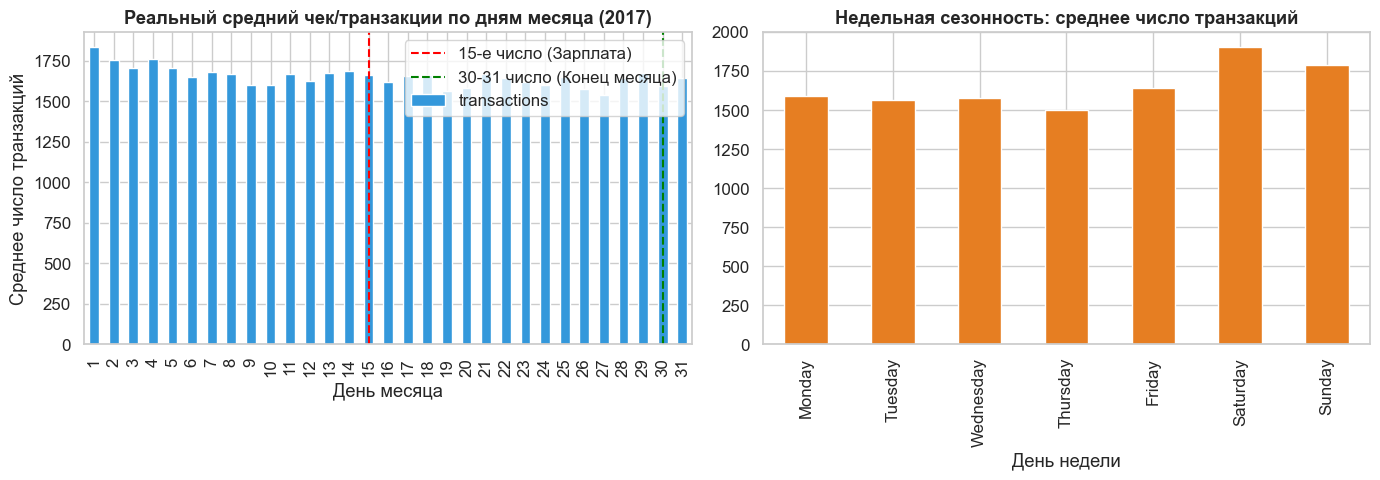

In [11]:
trans = pd.read_csv(config.DATA_DIR / 'transactions.csv', parse_dates=['date'])
trans_2017 = trans[trans['date'] >= '2017-01-01'].copy()
trans_2017['day'] = trans_2017['date'].dt.day
trans_2017['dayofweek'] = trans_2017['date'].dt.day_name()

# 1. График по дням месяца
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
day_traffic = trans_2017.groupby('day')['transactions'].mean()
day_traffic.plot(kind='bar', ax=ax1, color='#3498db')
ax1.set_title('Реальный средний чек/транзакции по дням месяца (2017)', fontweight='bold')
ax1.set_xlabel('День месяца')
ax1.set_ylabel('Среднее число транзакций')
ax1.axvline(14, color='red', linestyle='--', label='15-е число (Зарплата)')
ax1.axvline(29, color='green', linestyle='--', label='30-31 число (Конец месяца)')
ax1.legend()

# 2. График по дням недели
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_traffic = trans_2017.groupby('dayofweek')['transactions'].mean().reindex(dow_order)
dow_traffic.plot(kind='bar', ax=ax2, color='#e67e22')
ax2.set_title('Недельная сезонность: среднее число транзакций', fontweight='bold')
ax2.set_xlabel('День недели')

plt.tight_layout()
plt.show()

## 2. Реальная динамика цен на нефть (`oil.csv`)
Нефть WTI — ключевой драйвер экономики Эквадора. Посмотрим динамику цены в 2017 году.

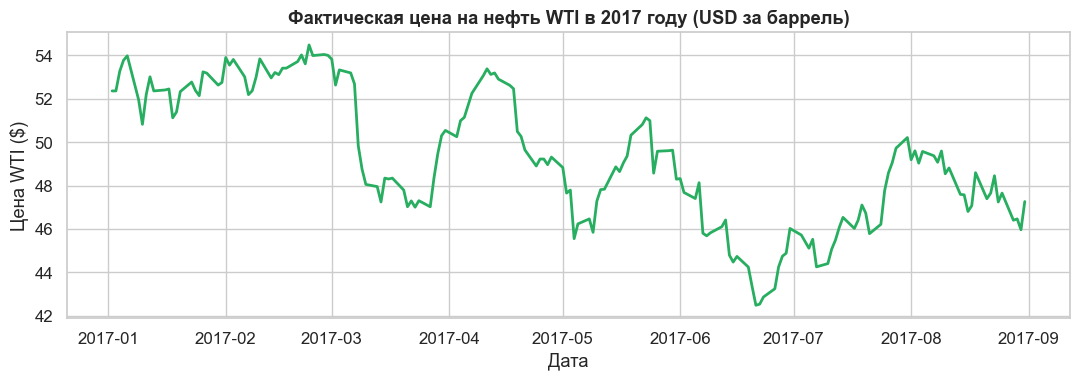

In [12]:
oil = pd.read_csv(config.DATA_DIR / 'oil.csv', parse_dates=['date'])
oil_2017 = oil[oil['date'] >= '2017-01-01'].copy()
oil_2017['dcoilwtico'] = oil_2017['dcoilwtico'].interpolate(method='linear').bfill().ffill()

plt.figure(figsize=(11, 4))
plt.plot(oil_2017['date'], oil_2017['dcoilwtico'], color='#27ae60', lw=2)
plt.title('Фактическая цена на нефть WTI в 2017 году (USD за баррель)', fontweight='bold')
plt.ylabel('Цена WTI ($)')
plt.xlabel('Дата')
plt.tight_layout()
plt.show()

## 3. Анализ категорий и скоропортящихся товаров (`items.csv`)
Посчитаем реальное распределение категорий товаров и долю скоропортящихся товаров (`perishable = 1`), которые получают вес 1.25 в формуле NWRMSLE.

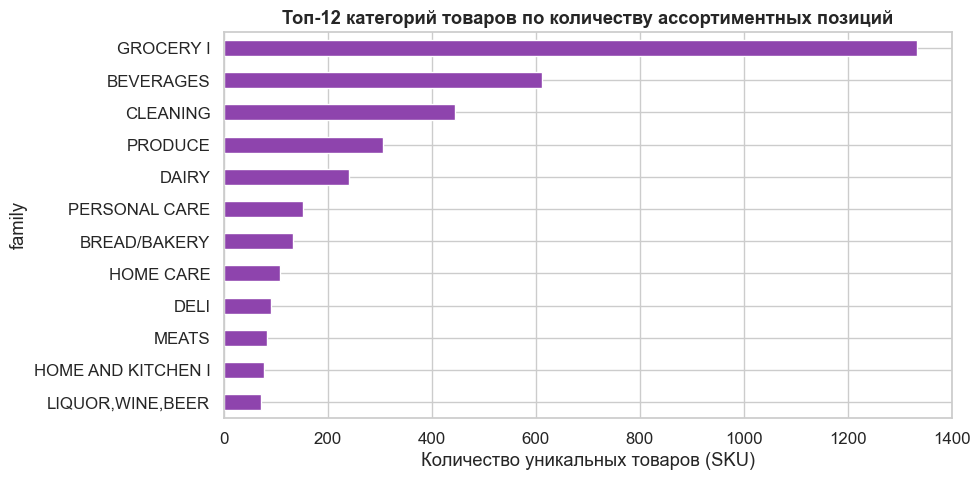

Доля обычных товаров (вес 1.0): 76.0%
Доля скоропортящихся товаров (вес 1.25): 24.0%


In [13]:
items = pd.read_csv(config.DATA_DIR / 'items.csv')
top_families = items['family'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top_families.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Топ-12 категорий товаров по количеству ассортиментных позиций', fontweight='bold')
ax.set_xlabel('Количество уникальных товаров (SKU)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

perish_share = items['perishable'].value_counts(normalize=True) * 100
print(f'Доля обычных товаров (вес 1.0): {perish_share[0]:.1f}%')
print(f'Доля скоропортящихся товаров (вес 1.25): {perish_share[1]:.1f}%')

## 4. Нули и разряженные продажи
Загрузим срез реальных продаж за июль-август 2017 года и посмотрим распределение продаж.

Загрузка train.csv (фильтрация: дата >= 2017-07-01)...
Train успешно загружен: 4,854,129 строк. Использование RAM: 101.8 MB


/Users/ivanbogush/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


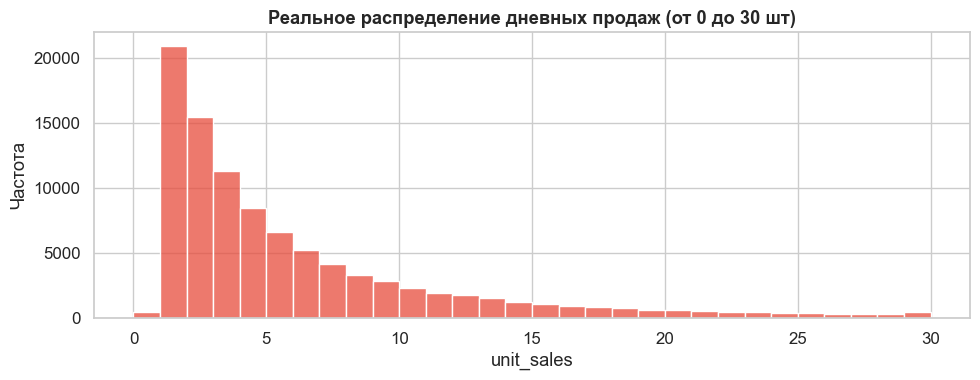

In [14]:
# Быстро загружаем реальный июль-август 2017 года
train_slice = load_train_data(start_date='2017-07-01')

plt.figure(figsize=(10, 4))
sales_sample = train_slice[config.TARGET_COL].sample(100000, random_state=42)
sns.histplot(sales_sample[sales_sample <= 30], bins=30, color='#e74c3c', kde=False)
plt.title('Реальное распределение дневных продаж (от 0 до 30 шт)', fontweight='bold')
plt.xlabel('unit_sales')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

## 5. Факт продаж с Seasonal Naive прогнозом
Возьмем конкретный популярный товар и магазин и построим  факт продаж за 16 дней валидации против бейзлайна.

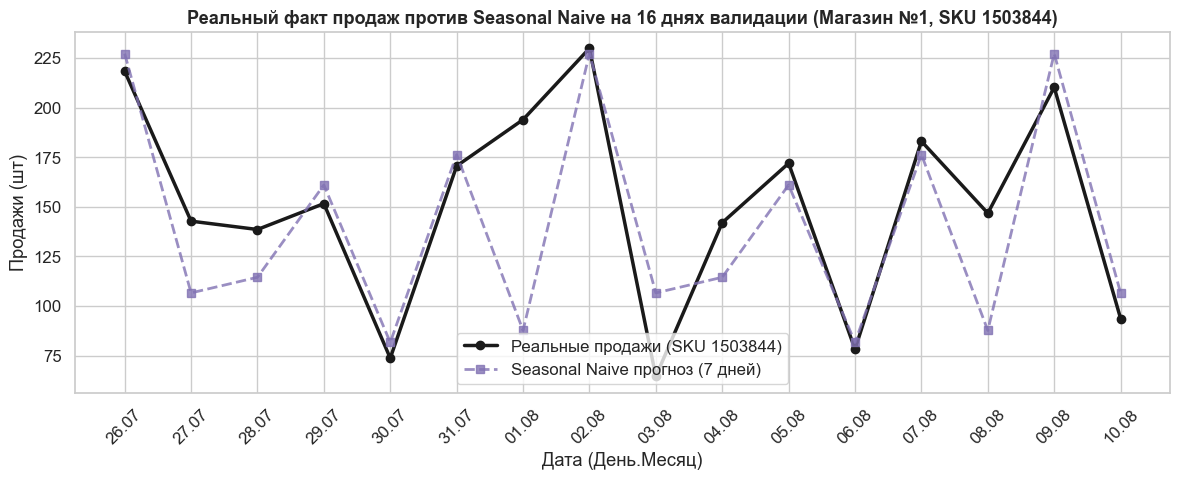

In [16]:
# 1. Товар с максимальными продажами в магазине №1
store_1 = train_slice[train_slice["store_nbr"] == 1]
top_item = store_1.groupby("item_nbr")["unit_sales"].sum().idxmax()

item_data = (
    store_1[store_1["item_nbr"] == top_item]
    .sort_values("date")
    .set_index("date")
)

# 2. Валидационный интервал
val_dates = pd.date_range("2017-07-26", "2017-08-10", freq="D")
actual_series = (
    item_data.loc[item_data.index.isin(val_dates), "unit_sales"]
    .reindex(val_dates, fill_value=0)
    .values
)

# 3. Seasonal Naive: прошлая неделя (19 - 25 июля)
prev_week_dates = pd.date_range("2017-07-19", "2017-07-25", freq="D")
prev_week = (
    item_data.loc[item_data.index.isin(prev_week_dates), "unit_sales"]
    .reindex(prev_week_dates, fill_value=0)
    .values
)
snaive_pred = np.tile(prev_week, 3)[:16]

# 4. Даты в виде текста (26.07 .. 10.08)
date_labels = [d.strftime("%d.%m") for d in val_dates]

# 5. Отрисовка
plt.figure(figsize=(12, 5))
plt.plot(
    date_labels,
    actual_series,
    "k-o",
    lw=2.5,
    label=f"Реальные продажи (SKU {top_item})",
)
plt.plot(
    date_labels,
    snaive_pred,
    "m--s",
    lw=2,
    alpha=0.8,
    label="Seasonal Naive прогноз (7 дней)",
)

plt.title(
    f"Реальный факт продаж против Seasonal Naive на 16 днях валидации (Магазин №1, SKU {top_item})",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Дата (День.Месяц)")
plt.ylabel("Продажи (шт)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()